# TASKS

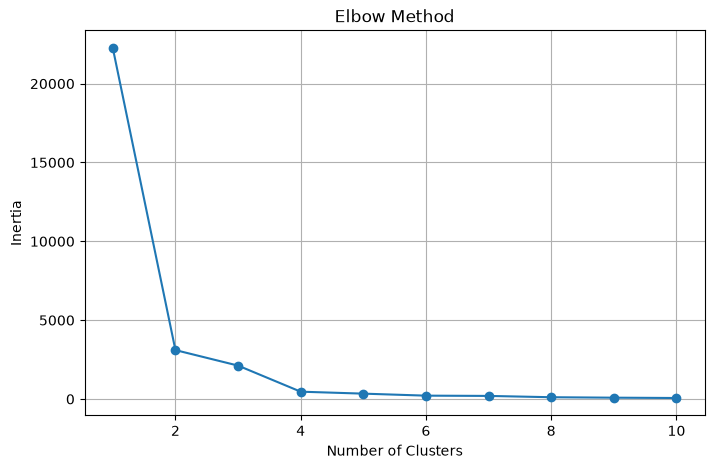

In [6]:
#Apply K-Means on Mall Customers Dataset & Plot Elbow Curve
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Select Annual Income and Spending Score
X = data.iloc[:, [3, 4]]

# Calculate inertia for different K values
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

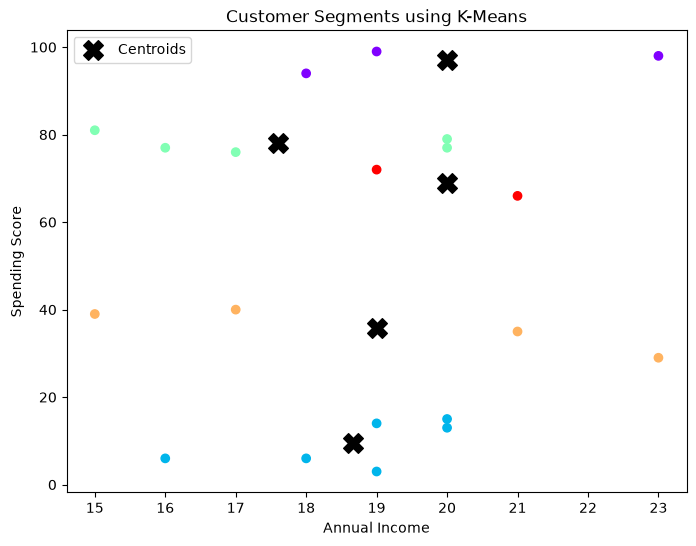

In [8]:
#Visualize Clusters Using Scatter Plot
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Features
X = data.iloc[:, [3, 4]]

# Train K-Means
kmeans = KMeans(n_clusters=5, random_state=42)

labels = kmeans.fit_predict(X)

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=labels,
    cmap='rainbow'
)

# Plot Centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments using K-Means")
plt.legend()

plt.show()

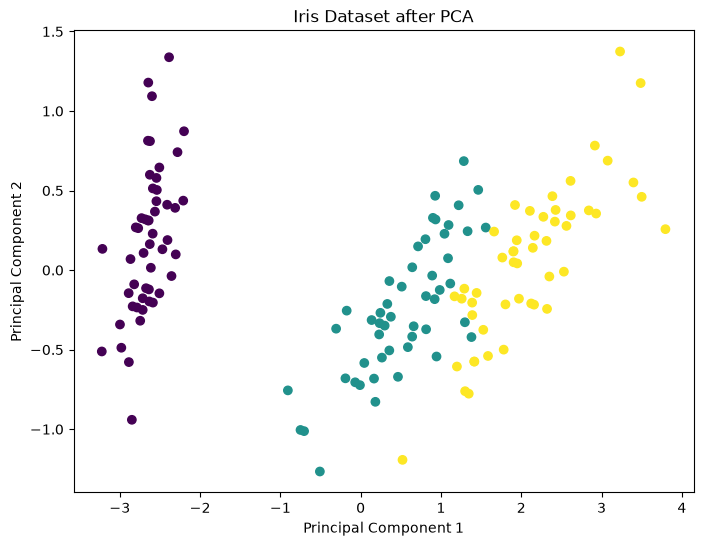

In [9]:
#Apply PCA to Reduce Iris Dataset to 2D
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset after PCA")

plt.show()

In [10]:
#Reconstruct Data from Top 2 Components & Measure Variance Explained
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import numpy as np

# Load dataset
iris = load_iris()

X = iris.data

# Apply PCA
pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X)

# Reconstruct original data
X_reconstructed = pca.inverse_transform(X_reduced)

# Explained Variance
print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")

print(np.sum(pca.explained_variance_ratio_))

# Reconstruction Error
error = np.mean((X - X_reconstructed)**2)

print("\nMean Squared Reconstruction Error:")

print(error)

Explained Variance Ratio:
[0.92461872 0.05306648]

Total Variance Explained:
0.9776852063187963

Mean Squared Reconstruction Error:
0.025341073932398255


# PRACTICE

🚀 Starting Machine Learning Mini-Project...

--- Part 1: Customer Segmentation ---
Successfully clustered 300 customers into 4 segments.
Used PCA to reduce 3D customer data to 2D for plotting.

--- Part 2: KNN vs. PCA+KNN ---
Dataset has 30 features.
1. Accuracy of KNN (using all 30 features): 95.91%
2. Accuracy of KNN (using only 5 PCA features): 95.91%
-> By keeping just 5 features, PCA retained 84.49% of the original dataset's variance (information)!

Generating dashboard (Close window to exit)...


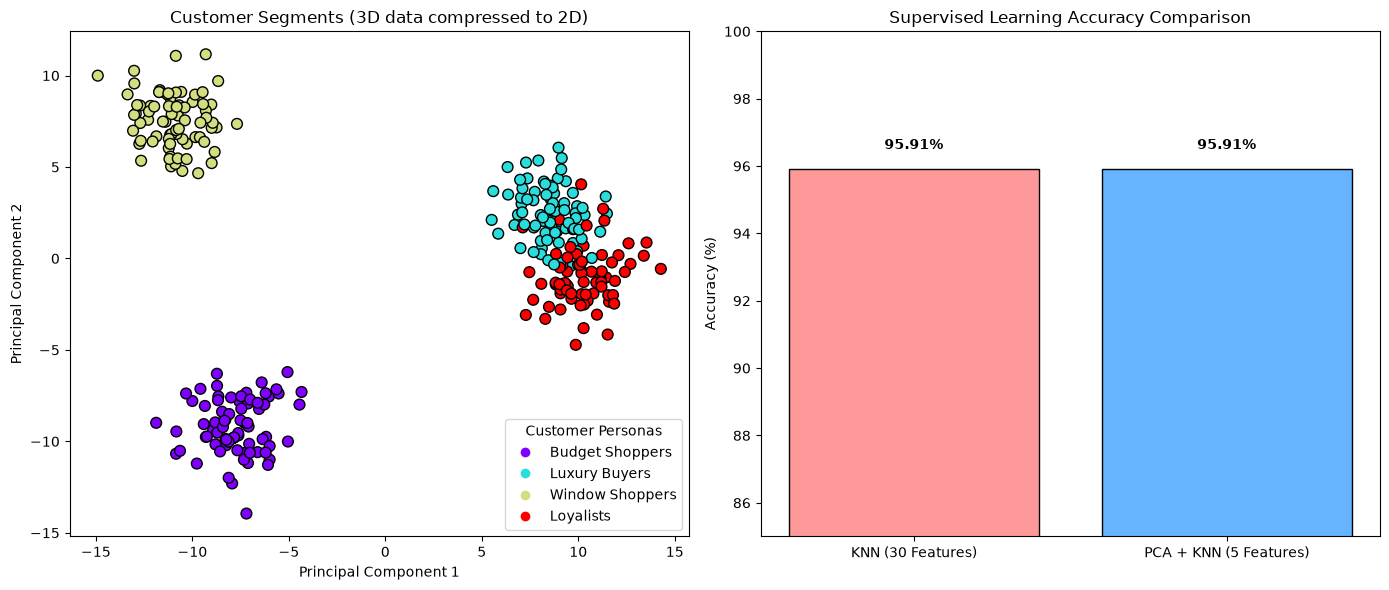

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def main():
    print("🚀 Starting Machine Learning Mini-Project...\n")

    # ==========================================
    # PART 1: CUSTOMER SEGMENTATION (K-MEANS)
    # ==========================================
    print("--- Part 1: Customer Segmentation ---")
    # Simulating 3D Customer Data: [Age, Annual Income, Spending Score]
    # We will create 4 distinct customer personas (centers=4)
    X_customers, _ = make_blobs(n_samples=300, centers=4, n_features=3, cluster_std=1.5, random_state=42)
    
    # 1. Apply K-Means
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    customer_segments = kmeans.fit_predict(X_customers)
    
    # 2. We have 3 features, which is hard to plot. Let's use PCA to reduce it to 2D!
    pca_2d = PCA(n_components=2)
    X_customers_2d = pca_2d.fit_transform(X_customers)
    
    print("Successfully clustered 300 customers into 4 segments.")
    print(f"Used PCA to reduce 3D customer data to 2D for plotting.\n")


    # ==========================================
    # PART 2: KNN WITH vs. WITHOUT PCA
    # ==========================================
    print("--- Part 2: KNN vs. PCA+KNN ---")
    # Load Breast Cancer dataset (30 features)
    cancer_data = load_breast_cancer()
    X_cancer = cancer_data.data
    y_cancer = cancer_data.target

    # Split into Study Guide (Train) and Final Exam (Test)
    X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.3, random_state=42)

    # ALWAY SCALE DATA before using distance-based algorithms (KNN & PCA)!
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- Test A: Normal KNN (All 30 Features) ---
    knn_normal = KNeighborsClassifier(n_neighbors=5)
    knn_normal.fit(X_train_scaled, y_train)
    normal_predictions = knn_normal.predict(X_test_scaled)
    acc_normal = accuracy_score(y_test, normal_predictions) * 100

    # --- Test B: PCA + KNN (Compress 30 features to just 5) ---
    pca_5d = PCA(n_components=5)
    
    # Train PCA on training data, and transform both train and test data
    X_train_pca = pca_5d.fit_transform(X_train_scaled)
    X_test_pca = pca_5d.transform(X_test_scaled)
    
    knn_pca = KNeighborsClassifier(n_neighbors=5)
    knn_pca.fit(X_train_pca, y_train)
    pca_predictions = knn_pca.predict(X_test_pca)
    acc_pca = accuracy_score(y_test, pca_predictions) * 100

    print(f"Dataset has {X_cancer.shape[1]} features.")
    print(f"1. Accuracy of KNN (using all 30 features): {acc_normal:.2f}%")
    print(f"2. Accuracy of KNN (using only 5 PCA features): {acc_pca:.2f}%")
    
    retained_variance = sum(pca_5d.explained_variance_ratio_) * 100
    print(f"-> By keeping just 5 features, PCA retained {retained_variance:.2f}% of the original dataset's variance (information)!")

    # ==========================================
    # VISUALIZATION
    # ==========================================
    print("\nGenerating dashboard (Close window to exit)...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Customer Segments
    scatter = axes[0].scatter(X_customers_2d[:, 0], X_customers_2d[:, 1], c=customer_segments, cmap='rainbow', edgecolor='k', s=60)
    axes[0].set_title('Customer Segments (3D data compressed to 2D)')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')
    
    # Add a nice legend for the customer groups
    handles, _ = scatter.legend_elements()
    axes[0].legend(handles, ["Budget Shoppers", "Luxury Buyers", "Window Shoppers", "Loyalists"], title="Customer Personas")

    # Plot 2: Accuracy Comparison Bar Chart
    labels = ['KNN (30 Features)', 'PCA + KNN (5 Features)']
    accuracies = [acc_normal, acc_pca]
    colors = ['#ff9999', '#66b3ff']
    
    bars = axes[1].bar(labels, accuracies, color=colors, edgecolor='black')
    axes[1].set_title('Supervised Learning Accuracy Comparison')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_ylim(85, 100) # Zoom in on the top part of the chart to see the difference
    
    # Add the text labels on top of the bars
    for bar in bars:
        yval = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()